In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Set style for better visuals
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/archive (3).zip'
output_dir = '/content/extracted_archive'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Contents of '{zip_file_path}' extracted to '{output_dir}'.")
print("Files extracted:")
for item in os.listdir(output_dir):
    print(f"- {item}")

Contents of '/content/drive/MyDrive/archive (3).zip' extracted to '/content/extracted_archive'.
Files extracted:
- credit_risk_dataset.csv


In [7]:
import pandas as pd

csv_file_path = '/content/extracted_archive/credit_risk_dataset.csv'
df = pd.read_csv(csv_file_path)
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Target variable distribution (1 = default, 0 = repaid)

In [8]:

print("\nTarget Distribution (TARGET):")
print(df['loan_status'].value_counts(normalize=True))
print(f"Default Rate: {df['loan_status'].mean()*100:.2f}%")


Target Distribution (TARGET):
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64
Default Rate: 21.82%


# Check missing values

In [9]:

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing %': df.isnull().mean() * 100
})
missing_df = missing_df[missing_df['Missing %'] > 0].sort_values('Missing %', ascending=False)
print(f"\nColumns with missing values: {len(missing_df)}")
print(missing_df.head(10))


Columns with missing values: 2
                              Column  Missing %
loan_int_rate          loan_int_rate   9.563856
person_emp_length  person_emp_length   2.747000


In [10]:
print("\n" + "="*50)
print("RISK VISUALIZATION")
print("="*50)



RISK VISUALIZATION


# Age distribution by default risk

In [41]:

df['person_age'] = abs(df['person_age'])
df['person_age'] = abs(df['person_age'])
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

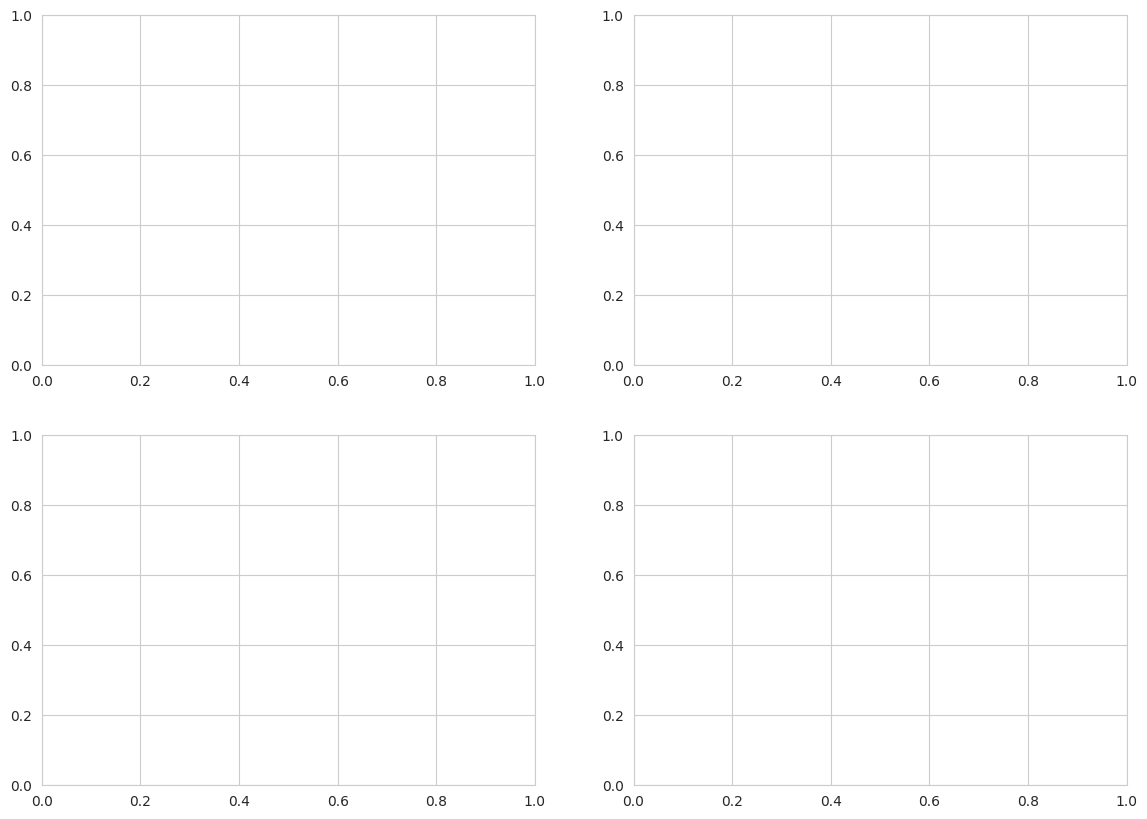

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#  Age vs Default

In [13]:

sns.kdeplot(data=df, x='person_age', hue='loan_status', fill=True, ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Default Risk')
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Density')

Text(4.444444444444452, 0.5, 'Density')

# Income vs Default

In [14]:

sns.boxplot(data=df, x='loan_status', y='person_income', ax=axes[0,1])
axes[0,1].set_title('Income Distribution by Default Risk')
axes[0,1].set_xlabel('Default (1=Yes, 0=No)')
axes[0,1].set_ylabel('Annual Income')

Text(596.2626262626262, 0.5, 'Annual Income')

# Loan Amount vs Default


In [42]:

sns.boxplot(data=df, x='loan_status', y='loan_amnt', ax=axes[1,0])
axes[1,0].set_title('Loan Amount by Default Risk')
axes[1,0].set_xlabel('Default (1=Yes, 0=No)')
axes[1,0].set_ylabel('Credit Amount')

Text(173.33333333333331, 0.5, 'Credit Amount')

# Employment Length vs Default

In [16]:

sns.kdeplot(data=df, x='person_emp_length', hue='loan_status', fill=True, ax=axes[1,1])
axes[1,1].set_title('Employment Length by Default Risk')
axes[1,1].set_xlabel('Years Employed')
axes[1,1].set_ylabel('Density')

Text(596.2626262626262, 0.5, 'Density')

In [17]:
plt.tight_layout()
fig.savefig('risk_analysis_visualizations.png', dpi=150)
print("✅ Saved visualizations to 'risk_analysis_visualizations.png'")
plt.show()

✅ Saved visualizations to 'risk_analysis_visualizations.png'


<Figure size 1200x600 with 0 Axes>

In [18]:
 #FEATURE ENGINEERING
# ==============================
print("\n" + "="*50)
print("FEATURE ENGINEERING")
print("="*50)


FEATURE ENGINEERING


In [19]:
# Create risk-related features
# app_train['INCOME_PER_PERSON'] = app_train['AMT_INCOME_TOTAL'] / (app_train['CNT_FAM_MEMBERS'] + 1) # 'CNT_FAM_MEMBERS' not in df
df['LOAN_TO_INCOME'] = df['loan_amnt'] / (df['person_income'] + 1)
# app_train['CREDIT_TERM'] = app_train['AMT_CREDIT'] / (app_train['AMT_ANNUITY'] + 1) # 'AMT_ANNUITY' not in df

In [20]:
# Handle extreme outliers in employment
df['person_emp_length'] = df['person_emp_length'].replace(123.0, np.nan)

# Features for modeling

In [43]:

feature_cols = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt',
    'loan_int_rate', 'cb_person_cred_hist_length', 'LOAN_TO_INCOME'
]

# Categorical features

In [22]:

categorical_cols = ['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']
for col in categorical_cols:
    if col in df.columns:
        feature_cols.append(col)

print(f"Selected {len(feature_cols)} features for modeling")

Selected 7 features for modeling


# PREPARE DATA FOR MODELING

# Handle missing values

In [44]:

X = df[feature_cols].copy()
y = df['loan_status'].copy()

# For categorical columns, I use mode imputation + label encoding

In [45]:

for col in X.select_dtypes(include=['object']).columns:
    X[col].fillna(X[col].mode()[0] if not X[col].mode().empty else 'Unknown', inplace=True)
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# I use median imputation numerical columns

In [26]:

for col in X.select_dtypes(include=[np.number]).columns:
    X[col].fillna(X[col].median(), inplace=True)

print(f"Final feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")


Final feature matrix shape: (32581, 7)
Target shape: (32581,)


/tmp/ipykernel_6874/1603740760.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)


# 7. TRAIN RISK PREDICTION MODEL

# Split data

In [28]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest

In [46]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("✅ Model training complete")

✅ Model training complete


In [30]:
# Predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# MODEL EVALUATION

In [47]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f} (Higher is better for risk separation)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

Accuracy: 0.8668
ROC-AUC Score: 0.8787 (Higher is better for risk separation)

Classification Report:
              precision    recall  f1-score   support

  No Default       0.89      0.95      0.92      5095
     Default       0.76      0.58      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.82      0.76      0.79      6517
weighted avg       0.86      0.87      0.86      6517



# Confusion Matrix

✅ Saved confusion matrix to 'confusion_matrix.png'


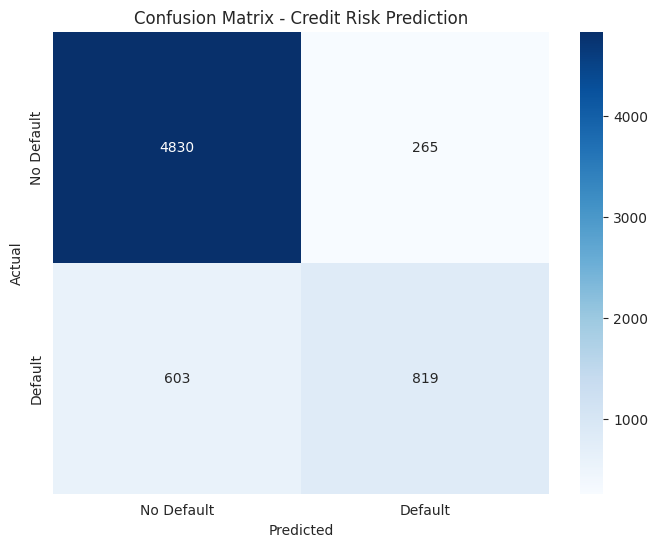

In [48]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Credit Risk Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150)
print("✅ Saved confusion matrix to 'confusion_matrix.png'")
plt.show()

# ROC Curve

✅ Saved ROC curve to 'roc_curve.png'


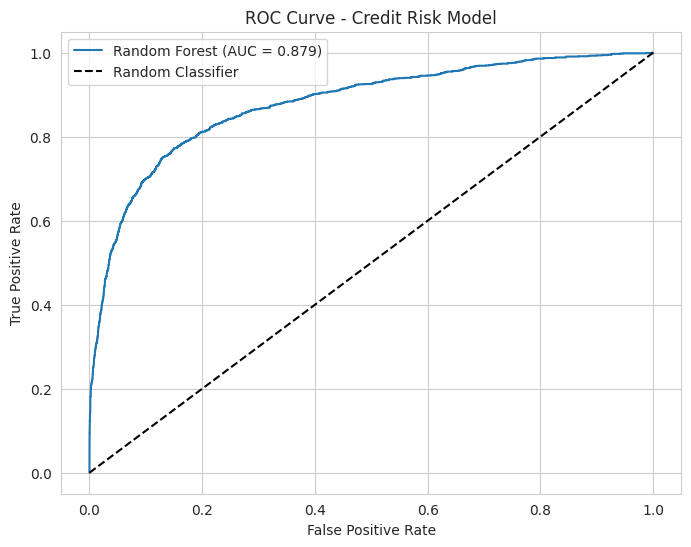

In [49]:

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Risk Model')
plt.legend()
plt.savefig('roc_curve.png', dpi=150)
print("✅ Saved ROC curve to 'roc_curve.png'")
plt.show()

# FEATURE IMPORTANCE (Risk Drivers)

In [36]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 most important features for predicting default:")
print(feature_importance.head(10))


Top 10 most important features for predicting default:
                      Feature  Importance
6              LOAN_TO_INCOME    0.394222
4               loan_int_rate    0.279312
1               person_income    0.206905
3                   loan_amnt    0.060688
2           person_emp_length    0.035780
0                  person_age    0.012845
5  cb_person_cred_hist_length    0.010249


/tmp/ipykernel_6874/3676772753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), y='Feature', x='Importance', palette='Reds_r')


✅ Saved feature importance to 'feature_importance.png'


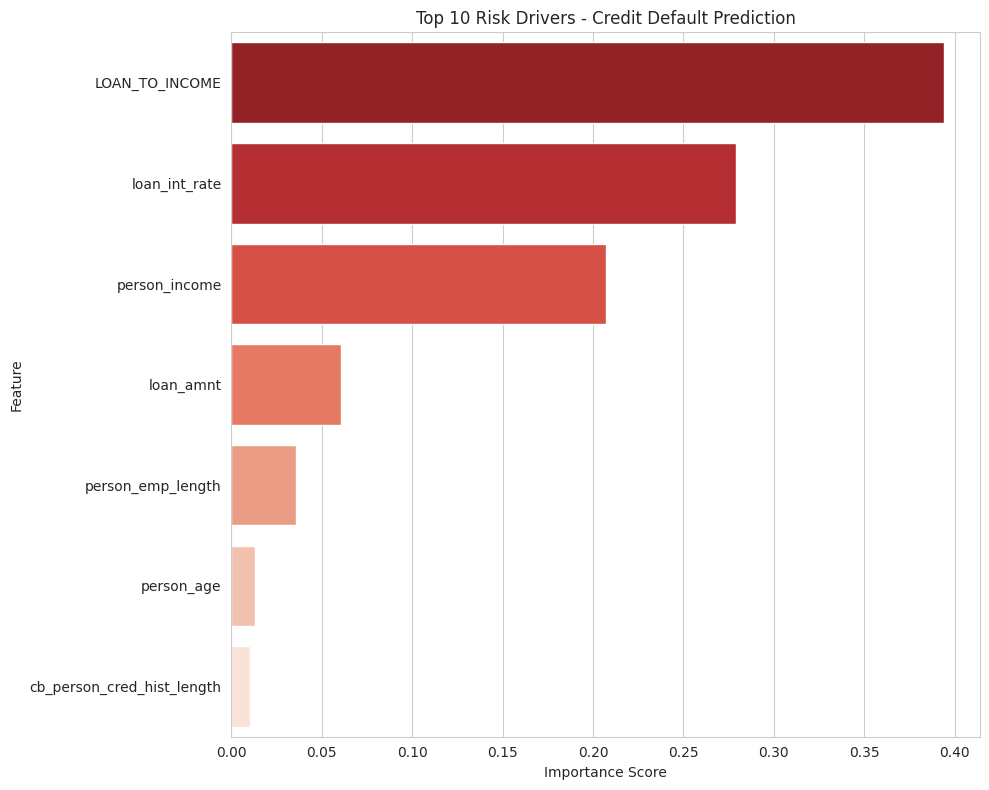

In [37]:
# Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), y='Feature', x='Importance', palette='Reds_r')
plt.title('Top 10 Risk Drivers - Credit Default Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
print("✅ Saved feature importance to 'feature_importance.png'")
plt.show()

# 10. SUMMARY FOR BITFINEX RISK

In [50]:




print(f"""
Key Findings for Risk Assessment:

1. Default Rate in Dataset: {df['loan_status'].mean()*100:.2f}%
2. Model ROC-AUC Score: {roc_auc:.3f} (Measures risk prediction quality)
3. Top Risk Drivers Identified:
   - {feature_importance.iloc[0]['Feature']}
   - {feature_importance.iloc[1]['Feature']}
   - {feature_importance.iloc[2]['Feature']}

 Relevance to Bitfinex Risk Department:
- This same methodology applies to detecting anomalous trading patterns
- Feature engineering principles work for transaction risk scoring
- ROC-AUC is a standard metric for fraud detection models
- Random Forest provides interpretable risk factors
""")

print("\n ANALYSIS COMPLETE")
print(" Output files generated:")
print("   - risk_analysis_visualizations.png")
print("   - confusion_matrix.png")
print("   - roc_curve.png")
print("   - feature_importance.png")


Key Findings for Risk Assessment:

1. Default Rate in Dataset: 21.82%
2. Model ROC-AUC Score: 0.879 (Measures risk prediction quality)
3. Top Risk Drivers Identified:
   - LOAN_TO_INCOME
   - loan_int_rate
   - person_income

 Relevance to Bitfinex Risk Department:
- This same methodology applies to detecting anomalous trading patterns
- Feature engineering principles work for transaction risk scoring
- ROC-AUC is a standard metric for fraud detection models
- Random Forest provides interpretable risk factors


 ANALYSIS COMPLETE
 Output files generated:
   - risk_analysis_visualizations.png
   - confusion_matrix.png
   - roc_curve.png
   - feature_importance.png


In [39]:
print(f"Total number of rows: {df.shape[0]}")
print(f"Total number of columns: {df.shape[1]}")

Total number of rows: 32581
Total number of columns: 13


In [40]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Number of numerical columns: {len(numerical_cols)}")
print(f"Number of categorical columns: {len(categorical_cols)}")

print("\nNumerical columns:")
print(list(numerical_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Number of numerical columns: 9
Number of categorical columns: 4

Numerical columns:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'LOAN_TO_INCOME']

Categorical columns:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
